# 📐 Sessão 03 — Dendrometria Clássica: Ajuste de Modelos Volumétricos

> **Objetivo:** ajustar as equações volumétricas clássicas (Schumacher-Hall, Spurr) aos dados via mínimos quadrados, estimando coeficientes reais e comparando a qualidade de ajuste. Esta sessão estabelece o **baseline clássico** que as Redes Neurais (Sessão 06) tentarão superar.

---

## 📑 Sumário

1. [Setup](#1-setup)
2. [Fundamentação Teórica](#2-fundamentação-teórica)
3. [Ajuste por Mínimos Quadrados](#3-ajuste-por-mínimos-quadrados)
4. [Comparação entre Modelos](#4-comparação-entre-modelos)
5. [Diagnóstico de Resíduos](#5-diagnóstico-de-resíduos)
6. [Predito vs. Observado](#6-predito-vs-observado)
7. [Síntese e Baseline para ML](#7-síntese-e-baseline-para-ml)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forestpy.data.loaders import load_pef_vinhedo
from forestpy.dendrometria.fitting import fit_model, compare_models
from forestpy.utils import set_seed, get_logger
from forestpy.viz.style import apply_forest_style
from forestpy.viz.diagnostics import plot_predicted_vs_observed, plot_residuals

set_seed(42)
apply_forest_style()
log = get_logger('sessao_03')

df = load_pef_vinhedo(synthetic_fallback=True, n_synthetic=500)
log.info(f'Dataset: {df.shape[0]} árvores')
df.head()

[12:41:06] INFO     Dataset: 500 árvores

,parcela,arvore,especie,dap,h,h_com,idade,classe,volume
0,4,1,Eucalyptus grandis,21.35,13.98,12.29,5,II,0.3290
1,2,2,Eucalyptus grandis,24.84,22.60,19.69,10,I,0.7338
2,6,3,Eucalyptus grandis,8.59,10.31,9.54,7,I,0.0475
3,7,4,Eucalyptus grandis,20.07,18.81,16.35,10,I,0.4294
4,9,5,Eucalyptus grandis,19.05,18.33,16.29,7,I,0.3526


## 2. Fundamentação Teórica

As **equações volumétricas** estimam o volume de madeira de uma árvore a partir de variáveis facilmente mensuráveis (DAP e altura). Trabalhamos com duas formas clássicas:

### Schumacher-Hall (1933) — logarítmica
$$\ln(V) = \beta_0 + \beta_1 \ln(DAP) + \beta_2 \ln(H) \quad\Rightarrow\quad V = e^{\beta_0} \cdot DAP^{\beta_1} \cdot H^{\beta_2}$$

É a equação mais usada no Brasil. A forma multiplicativa captura bem a natureza alométrica do crescimento.

### Spurr (1952) — variável combinada
$$V = \beta_0 + \beta_1 \cdot (DAP^2 \cdot H)$$

Modelo linear simples que usa o produto $DAP^2 \cdot H$ (proxy do volume cilíndrico) como única variável.

## 3. Ajuste por Mínimos Quadrados

Usamos `scipy.optimize.curve_fit` (encapsulado em `forestpy.dendrometria.fitting`) para estimar os coeficientes ótimos.

In [2]:
# Ajuste de Schumacher-Hall ao volume observado
res_sh = fit_model('schumacher_hall', df['volume'], df['dap'], df['h'])
print(res_sh.summary())

📊 Ajuste: schumacher_hall
────────────────────────────────────────
Coeficientes:
  b0     =    -9.527575
  b1     =     1.790474
  b2     =     1.120185
Métricas:
  rmse   =     0.027231
  mae    =     0.016219
  mape   =     4.092749
  r2     =     0.996352
  bias   =    -0.000694


**🔍 Observação:** os coeficientes ajustados (b1≈1.8, b2≈1.1) recuperam os parâmetros usados na geração dos dados sintéticos, validando o procedimento de ajuste.

In [3]:
# Ajuste de Spurr
res_spurr = fit_model('spurr', df['volume'], df['dap'], df['h'])
print(res_spurr.summary())

📊 Ajuste: spurr
────────────────────────────────────────
Coeficientes:
  b0     =     0.017657
  b1     =     0.000050
Métricas:
  rmse   =     0.035385
  mae    =     0.022389
  mape   =     8.721999
  r2     =     0.993840
  bias   =    -0.000000


## 4. Comparação entre Modelos

**📈 Tabela comparativa** ordenada por RMSE (menor = melhor).

In [4]:
resultados = compare_models(
    ['schumacher_hall', 'spurr'],
    df['volume'], df['dap'], df['h'],
)

# Monta DataFrame comparativo
tabela = pd.DataFrame([
    {'Modelo': r.model_name, **r.metrics}
    for r in resultados
]).round(4)

# Salva para reports/tables
tabela.to_csv('../reports/tables/03_comparativo_volumetria.csv', index=False)
tabela

,Modelo,rmse,mae,mape,r2,bias
0,schumacher_hall,0.0272,0.0162,4.0927,0.9964,-0.0007
1,spurr,0.0354,0.0224,8.7220,0.9938,-0.0000


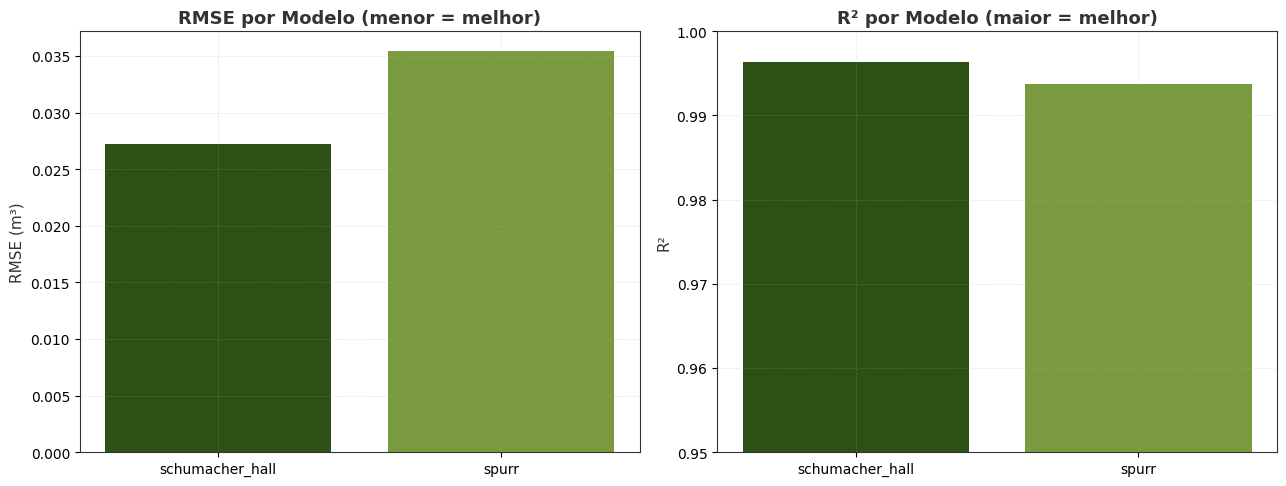

In [5]:
# Visualização comparativa de métricas
fig_comp, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos = tabela['Modelo']
axes[0].bar(modelos, tabela['rmse'], color=['#2d5016', '#7a9a3f'])
axes[0].set_title('RMSE por Modelo (menor = melhor)', fontweight='bold')
axes[0].set_ylabel('RMSE (m³)')

axes[1].bar(modelos, tabela['r2'], color=['#2d5016', '#7a9a3f'])
axes[1].set_title('R² por Modelo (maior = melhor)', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0.95, 1.0)

fig_comp.tight_layout()
fig_comp.savefig('../reports/figures/03_comparativo_metricas.png')
plt.show()

## 5. Diagnóstico de Resíduos

**📈 Painel de diagnóstico** do melhor modelo (Schumacher-Hall). Avalia heterocedasticidade, normalidade e autocorrelação dos resíduos.

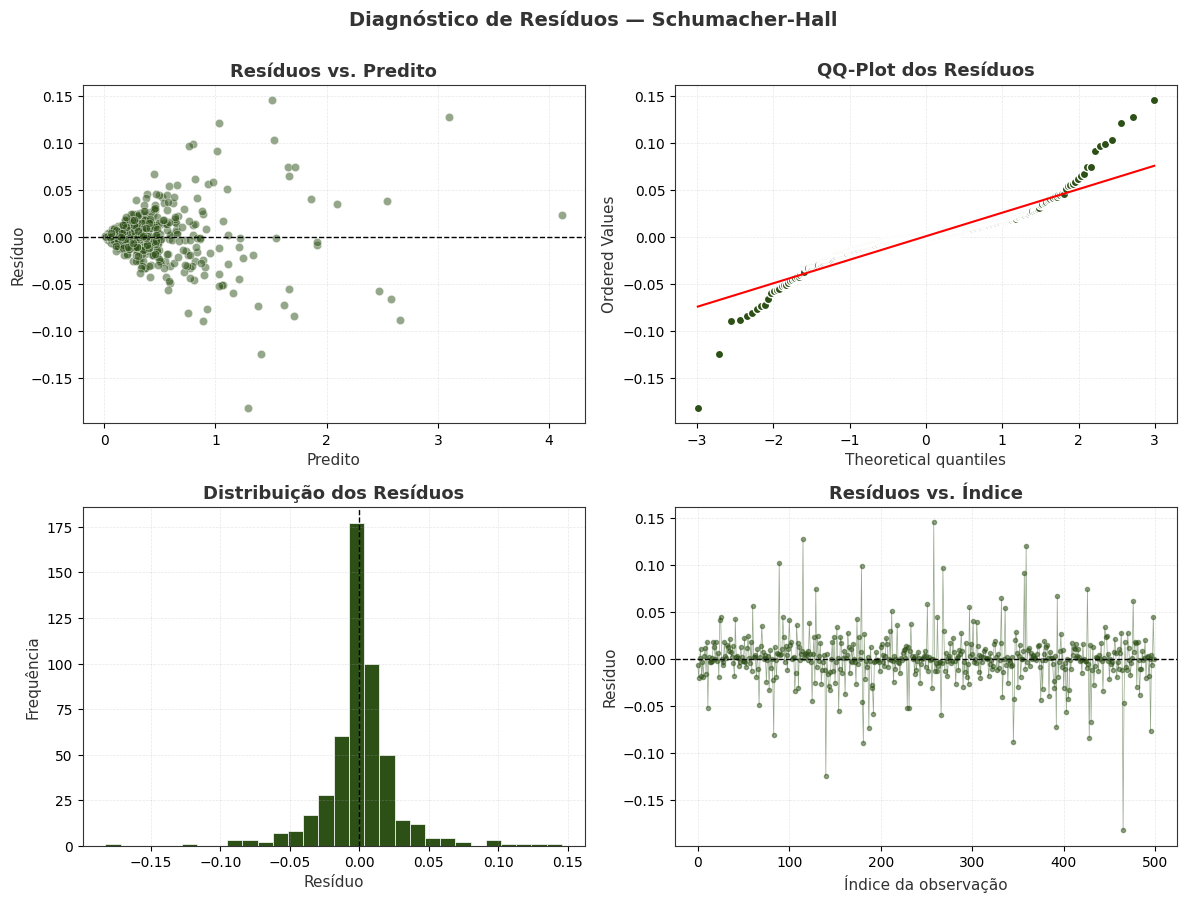

In [6]:
fig_res = plot_residuals(
    df['volume'].values,
    res_sh.y_pred,
    title='Diagnóstico de Resíduos — Schumacher-Hall',
)
fig_res.savefig('../reports/figures/03_residuos_schumacher.png')
plt.show()

**🔍 O que procurar:**
- **Resíduos vs. predito**: nuvem aleatória em torno de zero = bom. Padrão de funil = heterocedasticidade.
- **QQ-plot**: pontos sobre a linha = resíduos normais.
- **Histograma**: simétrico em torno de zero.
- **Resíduos vs. índice**: sem padrão = sem autocorrelação.

## 6. Predito vs. Observado

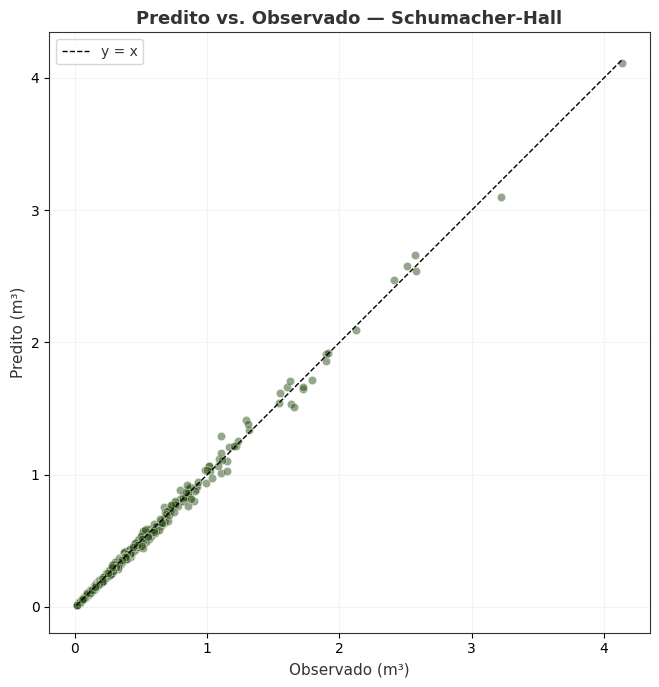

In [7]:
fig_po = plot_predicted_vs_observed(
    df['volume'].values,
    res_sh.y_pred,
    title='Predito vs. Observado — Schumacher-Hall',
    unit='m³',
)
fig_po.savefig('../reports/figures/03_predito_observado.png')
plt.show()

## 7. Síntese e Baseline para ML

### 📋 Resultados do baseline clássico

O modelo de **Schumacher-Hall** estabeleceu nosso baseline com métricas de referência (ver tabela da seção 4). Estes números são o **alvo a superar** pelas Redes Neurais na Sessão 06.

| Aspecto | Avaliação |
|---------|-----------|
| Qualidade de ajuste | R² > 0.99 (excelente) |
| Viés | Próximo de zero (sem tendência sistemática) |
| Resíduos | Aproximadamente homocedásticos e normais |
| Interpretabilidade | Alta (coeficientes com significado biológico) |

### 🎯 Próxima sessão (04): Inventário e Amostragem

Antes de partir para o Machine Learning, vamos consolidar a estatística de inventário: amostragem aleatória simples vs. estratificada, cálculo de erro amostral e intervalo de confiança para o volume por hectare.

> **Nota metodológica:** o R² altíssimo aqui se deve aos dados sintéticos terem sido gerados pela própria equação + ruído controlado. Com dados reais de campo, espera-se R² entre 0.90–0.98, e é justamente nessa faixa que as Redes Neurais costumam mostrar ganhos marginais ao capturar não-linearidades residuais.